# Задание 1

In [89]:
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import re
from IPython.display import display

### Этап 1 и 2. Реализация базового класса Account

Задача создать базовый класс accaunt и добавить методы для данного класса согласно этапу 1 и 2

In [90]:
# Определение базового класса Account
class Account:
    """
    Базовый класс банковского счёта.
    Основная задача хранить историю операций, проверка корректности данных, отображение и визуализацию истории.
    """

    # Приватный счётчик для генерации уникальных номеров счетов
    _account_counter = 1001

    def __init__(self, account_holder: str, balance: float = 0.0):
       
        """
        Конструктор класса Account.
        :param account_holder: имя владельца счёта ("Имя Фамилия")
        :param balance: начальный баланс (по умолчанию 0)
        """
        # Проверка имени владельца
        if not self._validate_name(account_holder):
            raise ValueError("Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв.")
        # Проверка баланса
        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным.")


        # Генерация уникального номера счёта в формате ACC-XXXX
        self.account_number = f"ACC-{Account._account_counter:04d}"
        Account._account_counter += 1

        # Инициализация атрибутов
        self.holder = account_holder.strip()
        self._balance = balance
        self.operations_history = []  # список словарей с операциями

    # Валидация имени владельца
    @staticmethod
    def _validate_name(name: str) -> bool:
        """Проверка формата имени: 'Имя Фамилия' с заглавных букв. Допускается латиница и кирилица"""
        pattern = r"^[А-ЯA-Z][а-яa-z]+ [А-ЯA-Z][а-яa-z]+$"
        return re.match(pattern, name.strip()) is not None

    # Добавление записи в историю операций
    def _add_operation(self, op_type: str, amount: float, status: str):
        """Добавляет запись операции в историю каждая запись содержит:тип, сумму, дату/время, баланс и статус (успех/ошибка)"""
        now = datetime.now().replace(microsecond=0)  # убираем микросекунды
        self.operations_history.append({
            "account_holder": self.holder,
            "account_number": self.account_number,
            "type": op_type,
            "amount": amount,
            "datetime": now,
            "balance_after": self._balance,
            "status": status
    })


    # Пополнение счёта

    def deposit(self, amount: float):
        """Пополнение счёта."""
        if amount <= 0:
            raise ValueError("Сумма пополнения должна быть положительной.")
        self._balance += amount
        self._add_operation("deposit", amount, "success")


    # Снятие средств

    def withdraw(self, amount: float):
        """Снятие средств. Проверка на достаточность баланса."""
        if amount <= 0:
            raise ValueError("Сумма снятия должна быть положительной.")
        if amount > self._balance:
            self._add_operation("withdraw", amount, "fail")
        else:
            self._balance -= amount
            self._add_operation("withdraw", amount, "success")

    # Получение текущего баланса

    def get_balance(self) -> float:
        return self._balance

    # Получение истории операций

    def get_history(self):
        """Возвращает историю операций в виде списка словарей."""
        return self.operations_history

    # Отображение истории операций

    def show_history(self):
        """Отображение истории операций в таблице с именем владельца."""
        if not self.operations_history:
            print("История операций пуста.")
            return
        df = pd.DataFrame(self.operations_history)
        display(df)

    # Визуализация истории баланса

    def plot_history(self):
        """Построение графика изменения баланса по времени с точными метками операций."""
        if not self.operations_history:
            print("Нет операций для отображения.")
            return

        df = pd.DataFrame(self.operations_history)
        df = df[df["status"] == "success"]
        if df.empty:
            print("Нет успешных операций для отображения.")
            return

        # Преобразуем datetime в строки нужного формата
        df['datetime_str'] = df['datetime'].dt.strftime("%Y-%m-%d %H:%M:%S")

        # Строим график: ось X — индекс операций, подписи — datetime
        plt.figure(figsize=(10, 5))
        plt.plot(df.index, df["balance_after"], marker='o', linestyle='-')

        # Подписи по оси X
        plt.xticks(ticks=df.index, labels=df['datetime_str'], rotation=45, ha='right')

        # Подписи и оформление
        plt.title(f"Изменение баланса по счёту {self.account_number}")
        plt.xlabel("Дата и время операции")
        plt.ylabel("Баланс, ₽")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    # Анализ крупных операций

    def get_top_operations(self, n: int = 3):
        """Возвращает последние n крупных успешных операций."""
        df = pd.DataFrame(self.operations_history)
        if df.empty:
            print("История операций пуста.")
            return
        df = df[df["status"] == "success"]
        df = df.sort_values(by=["amount", "datetime"], ascending=[False, False])
        top_df = df.head(n)
        display(top_df)

Проверим работу методов

In [91]:
# Создаём объект
acc2 = Account("Петр Петров", 1000)

# Пополняем счёт
acc2.deposit(500)

# Пытаемся снять больше, чем есть (должна быть неудача)
acc2.withdraw(3000)

# Снимаем допустимую сумму
acc2.withdraw(200)

# Проверяем баланс и историю
print("Текущий баланс:", acc2.get_balance())
acc2.show_history()

Текущий баланс: 1300


,account_holder,account_number,type,amount,datetime,balance_after,status
0,Петр Петров,ACC-1001,deposit,500,2025-11-08 23:19:55,1500,success
1,Петр Петров,ACC-1001,withdraw,3000,2025-11-08 23:19:55,1500,fail
2,Петр Петров,ACC-1001,withdraw,200,2025-11-08 23:19:55,1300,success


### ЭТАП 3. Визуализация истории операций (дополнительное задание)

Задача этапа с помощью библиотеки Pandas создать DataFrame из истории и визуализировать изменение баланса во времени.

Метод визуализции был добавлен выше для простоты. Теперь необходимо создать тестовый счет и визуализировать историю

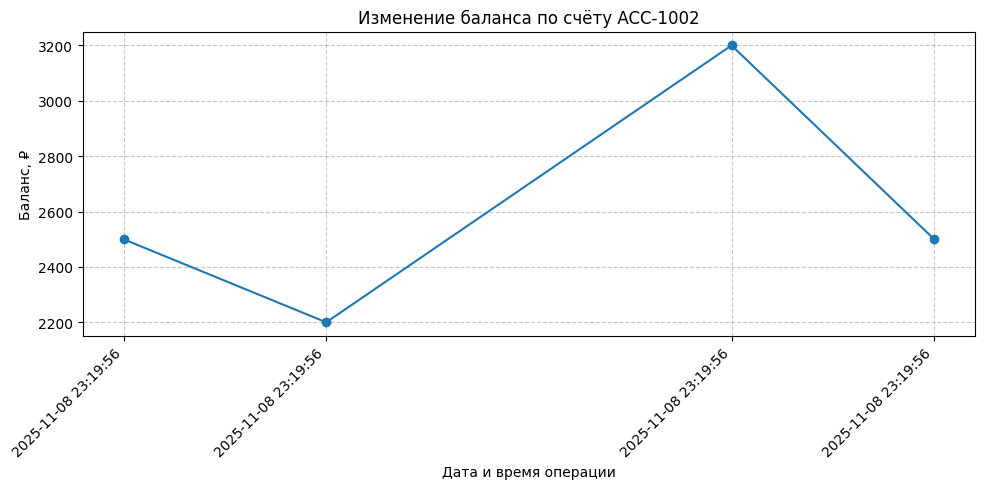

In [92]:
acc3 = Account("Сидоров Петя ", 2000)
acc3.deposit(500)
acc3.withdraw(300)
acc3.withdraw(5000)  # неудачная операция
acc3.deposit(1000)
acc3.withdraw(700)

acc3.plot_history()

### Задание 2 — Наследование

### Этап 4

In [93]:

class CheckingAccount(Account):
    """Расчётный счёт (наследник Account)."""
    account_type = "Расчётный счёт"
    
    # для задания 3
    def load_history(self, file_path: str):
        """Загрузка истории из CSV или JSON и добавление в аккаунт"""
        # Загружаем данные
        if file_path.endswith(".csv"):
            df = pd.read_csv(file_path)
        elif file_path.endswith(".json"):
            df = pd.read_json(file_path)
        else:
            raise ValueError("Поддерживаются только CSV и JSON файлы")

        # Очистка данных
        df_clean = self.clean_history(df)

        # Добавление операций и обновление баланса
        for _, row in df_clean.iterrows():
            # Преобразуем datetime из строки в объект datetime
            if isinstance(row['date'], str):
                dt = datetime.strptime(row['date'], "%Y-%m-%d %H:%M:%S")
            else:
                dt = row['date']

            # Обновляем баланс в зависимости от типа операции
            if row['operation'] == 'deposit':
                self._balance += row['amount']
            elif row['operation'] == 'withdraw':
                self._balance -= row['amount']

            # Формируем запись в историю в стандартном формате
            self.operations_history.append({
                "account_holder": self.holder,
                "account_number": self.account_number,
                "type": row['operation'],
                "amount": row['amount'],
                "datetime": dt,
                "balance_after": self._balance,
                "status": "success"
            })

    def clean_history(self, df: pd.DataFrame) -> pd.DataFrame:
        """Фильтрация некорректных данных для CheckingAccount"""
        allowed_types = ['deposit', 'withdraw']

        # Фильтрация по типу операции и положительной сумме
        df_valid = df[(df['operation'].isin(allowed_types)) & (df['amount'] > 0)]

        # Проверка корректности даты
        def valid_datetime(dt):
            try:
                if isinstance(dt, str):
                    datetime.strptime(dt, "%Y-%m-%d %H:%M:%S")
                return True
            except:
                return False

        df_valid = df_valid[df_valid['date'].apply(valid_datetime)]
        df_valid = df_valid.reset_index(drop=True)
        return df_valid

Класс сберегательного счёта

In [94]:
class SavingsAccount(Account):
    """Сберегательный счёт (наследник Account)."""
    account_type = "Сберегательный счёт"

    def withdraw(self, amount: float):
        """Переопределённое снятие: нельзя снять >50% баланса."""
        if amount <= 0:
            raise ValueError("Сумма снятия должна быть положительной.")
        if amount > self._balance * 0.5:
            print("Нельзя снять больше 50% от текущего баланса.")
            self._add_operation("withdraw", amount, "fail")
        else:
            self._balance -= amount
            self._add_operation("withdraw", amount, "success")

    def apply_interest(self, rate: float):
        """Начисление процентов на остаток."""
        if rate <= 0:
            raise ValueError("Процентная ставка должна быть положительной.")
        interest = self._balance * (rate / 100)
        self._balance += interest
        self._add_operation("interest", interest, "success")
    
    def load_history(self, file_path: str):
        """Загрузка истории из CSV или JSON и добавление в аккаунт"""
        if file_path.endswith(".csv"):
            df = pd.read_csv(file_path)
        elif file_path.endswith(".json"):
            df = pd.read_json(file_path)
        else:
            raise ValueError("Поддерживаются только CSV и JSON файлы")

        df_clean = self.clean_history(df)

        for _, row in df_clean.iterrows():
            if isinstance(row['date'], str):
                dt = datetime.strptime(row['date'], "%Y-%m-%d %H:%M:%S")
            else:
                dt = row['date']

            if row['operation'] == 'deposit':
                self._balance += row['amount']
            elif row['operation'] == 'withdraw':
                self._balance -= row['amount']
            elif row['operation'] == 'interest':
                self._balance += row['amount']

            self.operations_history.append({
                "account_holder": self.holder,
                "account_number": self.account_number,
                "type": row['operation'],
                "amount": row['amount'],
                "datetime": dt,
                "balance_after": self._balance,
                "status": "success"
            })

    def clean_history(self, df: pd.DataFrame) -> pd.DataFrame:
        """Фильтрация некорректных данных для SavingsAccount"""
        allowed_types = ['deposit', 'withdraw', 'interest']
        df_valid = df[(df['operation'].isin(allowed_types)) & (df['amount'] > 0)]

        def valid_datetime(dt):
            try:
                if isinstance(dt, str):
                    datetime.strptime(dt, "%Y-%m-%d %H:%M:%S")
                return True
            except:
                return False

        df_valid = df_valid[df_valid['date'].apply(valid_datetime)]
        df_valid = df_valid.reset_index(drop=True)
        return df_valid

### Вывод результатов по заданию 2

In [95]:

# Создание счетов
chk = CheckingAccount("Иван Иванов", 1500)
sav = SavingsAccount("Петр Петров", 2000)

# Выполнение операций
chk.deposit(1000)
chk.withdraw(500)
chk.withdraw(3000)  # неудачная операция

sav.deposit(500)
sav.withdraw(1200)  # превышает 50% — неудача
sav.withdraw(900)   # допустимо
sav.apply_interest(7)  # начисляем проценты

# Просмотр истории
print(f"История операций по счёту {chk.holder} ({chk.account_type}):")
chk.show_history()

print(f"\nИстория операций по счёту {sav.holder} ({sav.account_type}):")
sav.show_history()

# Анализ крупных операций
print(f"\nТоп крупных операций по счёту {chk.holder}:")
chk.get_top_operations(2)

Нельзя снять больше 50% от текущего баланса.
История операций по счёту Иван Иванов (Расчётный счёт):


,account_holder,account_number,type,amount,datetime,balance_after,status
0,Иван Иванов,ACC-1003,deposit,1000,2025-11-08 23:19:58,2500,success
1,Иван Иванов,ACC-1003,withdraw,500,2025-11-08 23:19:58,2000,success
2,Иван Иванов,ACC-1003,withdraw,3000,2025-11-08 23:19:58,2000,fail



История операций по счёту Петр Петров (Сберегательный счёт):


,account_holder,account_number,type,amount,datetime,balance_after,status
0,Петр Петров,ACC-1004,deposit,500.0,2025-11-08 23:19:58,2500.0,success
1,Петр Петров,ACC-1004,withdraw,1200.0,2025-11-08 23:19:58,1300.0,success
2,Петр Петров,ACC-1004,withdraw,900.0,2025-11-08 23:19:58,1300.0,fail
3,Петр Петров,ACC-1004,interest,91.0,2025-11-08 23:19:58,1391.0,success



Топ крупных операций по счёту Иван Иванов:


,account_holder,account_number,type,amount,datetime,balance_after,status
0,Иван Иванов,ACC-1003,deposit,1000,2025-11-08 23:19:58,2500,success
1,Иван Иванов,ACC-1003,withdraw,500,2025-11-08 23:19:58,2000,success


# Задание 3

In [96]:
# Создаём аккаунты
chk = CheckingAccount("Кондратьев Влад", 1500)
sav = SavingsAccount("Павлов Игорь", 2000)

# Загружаем историю из «грязных» файлов
chk.load_history("transactions_dirty.csv")
sav.load_history("transactions_dirty.json")

# Просмотр истории и текущего баланса
chk.show_history()
print("Баланс CheckingAccount:", chk.get_balance())

sav.show_history()
print("Баланс SavingsAccount:", sav.get_balance())

,account_holder,account_number,type,amount,datetime,balance_after,status
0,Кондратьев Влад,ACC-1005,deposit,921.0,2025-09-27 22:17:26,2421.0,success
1,Кондратьев Влад,ACC-1005,deposit,607.0,2025-09-27 22:17:26,3028.0,success
2,Кондратьев Влад,ACC-1005,deposit,488.0,2025-09-28 22:17:26,3516.0,success
3,Кондратьев Влад,ACC-1005,deposit,880.0,2025-09-29 22:17:26,4396.0,success
4,Кондратьев Влад,ACC-1005,withdraw,352.0,2025-10-01 22:17:26,4044.0,success
...,...,...,...,...,...,...,...
59,Кондратьев Влад,ACC-1005,deposit,864.0,2025-10-17 22:17:26,17441.0,success
60,Кондратьев Влад,ACC-1005,deposit,671.0,2025-10-19 22:17:26,18112.0,success
61,Кондратьев Влад,ACC-1005,deposit,696.0,2025-10-19 22:17:26,18808.0,success
62,Кондратьев Влад,ACC-1005,withdraw,300.0,2025-10-19 22:17:26,18508.0,success


Баланс CheckingAccount: 18115.0


,account_holder,account_number,type,amount,datetime,balance_after,status
0,Павлов Игорь,ACC-1006,deposit,921.00,2025-09-27 22:17:26,2921.00,success
1,Павлов Игорь,ACC-1006,deposit,607.00,2025-09-27 22:17:26,3528.00,success
2,Павлов Игорь,ACC-1006,deposit,488.00,2025-09-28 22:17:26,4016.00,success
3,Павлов Игорь,ACC-1006,deposit,880.00,2025-09-29 22:17:26,4896.00,success
4,Павлов Игорь,ACC-1006,withdraw,352.00,2025-10-01 22:17:26,4544.00,success
...,...,...,...,...,...,...,...
71,Павлов Игорь,ACC-1006,deposit,671.00,2025-10-19 22:17:26,23054.91,success
72,Павлов Игорь,ACC-1006,interest,503.25,2025-10-19 22:17:26,23558.16,success
73,Павлов Игорь,ACC-1006,deposit,696.00,2025-10-19 22:17:26,24254.16,success
74,Павлов Игорь,ACC-1006,withdraw,300.00,2025-10-19 22:17:26,23954.16,success


Баланс SavingsAccount: 23561.16
